Starter Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']

# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


Helper Function

In [16]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
    validation_data=(x_v, to_categorical(y_v, 10)),
    epochs=epochs, batch_size=batch_size,
    callbacks=cb, verbose=0)

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time:{elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed

def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

1A. Normalization Comparison

In [4]:
# build baseline model for CNN
def BaselineCNN():
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(32,(3,3), activation= "relu", padding= "same"),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64,(3,3), activation= "relu", padding= "same"),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation= "relu"),
        layers.Dense(10, activation= "softmax")
    ])
    return model

In [5]:
# ExperimentA: No normalization
x_train_A = x_train
x_val_A = x_val
x_test_A = x_test

model_A = BaselineCNN()
model_A.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("ExperimentA: No normalization")
hist_A, acc_A, loss_A, time_A = train_and_evaluate(
    model_A, x_train_A, y_train, x_val_A, y_val, x_test_A, y_test
)


ExperimentA: No normalization
Test Acc: 0.5553 | Test Loss: 3.2533 | Time:148.3s


In [6]:
# ExperimentB: Min-Max normalization
x_train_B = x_train / 255
x_val_B = x_val / 255
x_test_B = x_test / 255

model_B = BaselineCNN()
model_B.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("ExperimentB: Min-Max normalization")
hist_B, acc_B, loss_B, time_B = train_and_evaluate(
    model_B, x_train_B, y_train, x_val_B, y_val, x_test_B, y_test
)


ExperimentB: Min-Max normalization
Test Acc: 0.6417 | Test Loss: 1.5320 | Time:141.9s


In [7]:
# ExperimentC: Standardization per-channel
mean = np.mean(x_train, axis= (0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))
x_train_C = (x_train - mean) / std
x_val_C = (x_val - mean) / std
x_test_C = (x_test - mean) / std

model_C = BaselineCNN()
model_C.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("ExperimentC: Standardization per-channel")
hist_C, acc_C, loss_C, time_C = train_and_evaluate(
    model_C, x_train_C, y_train, x_val_C, y_val, x_test_C, y_test
)

ExperimentC: Standardization per-channel
Test Acc: 0.6627 | Test Loss: 2.2792 | Time:139.9s


In [18]:
print(hist_A.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


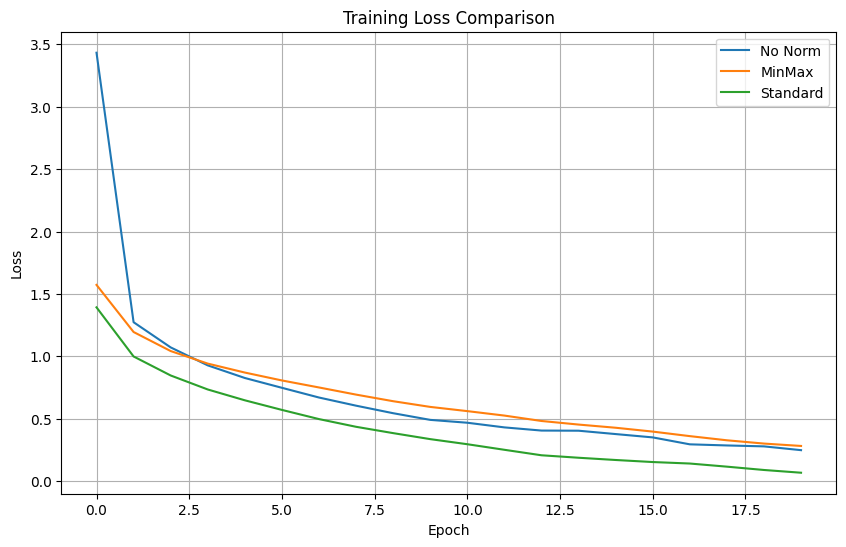

In [ ]:
# training loss curves
plot_curves(
    histories=[hist_A,hist_B,hist_C], 
    labels=['No Norm', 'MinMax', 'Standard'], 
    metric='loss', 
    title='Training Loss Comparison', 
    ylabel='Loss'
)


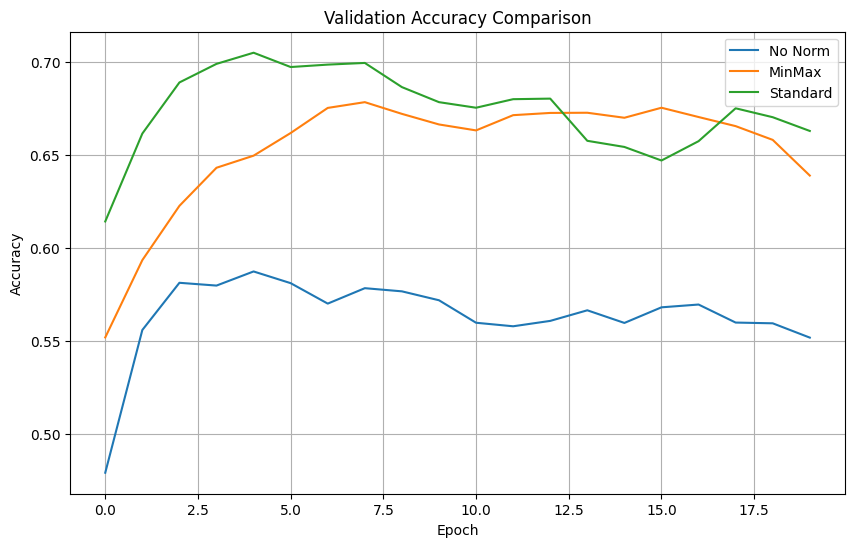

In [ ]:
# validation accuracy curves
plot_curves(
    histories=[hist_A, hist_B, hist_C],
    labels=['No Norm', 'MinMax', 'Standard'],
    metric='val_accuracy',
    title='Validation Accuracy Comparison',
    ylabel='Accuracy'
)

In [27]:
# results table
acc_A_train = hist_A.history['accuracy'][-1]
acc_B_train = hist_B.history['accuracy'][-1]
acc_C_train = hist_C.history['accuracy'][-1]

acc_A_val = hist_A.history['val_accuracy'][-1]
acc_B_val = hist_B.history['val_accuracy'][-1]
acc_C_val = hist_C.history['val_accuracy'][-1]

loss1_A = hist_A.history['loss'][0]
loss1_B = hist_B.history['loss'][0]
loss1_C = hist_C.history['loss'][0]

print("Results Table")
print(f"None         | Train Acc: {acc_A_train:.4f} | Val Acc: {acc_A_val:.4f} | Test Acc: {acc_A:.4f} | Loss@1: {loss1_A:.4f}")
print(f"Min-Max      | Train Acc: {acc_B_train:.4f} | Val Acc: {acc_B_val:.4f} | Test Acc: {acc_B:.4f} | Loss@1: {loss1_B:.4f}")
print(f"Standardized | Train Acc: {acc_C_train:.4f} | Val Acc: {acc_C_val:.4f} | Test Acc: {acc_C:.4f} | Loss@1: {loss1_C:.4f}")

Results Table
None         | Train Acc: 0.9135 | Val Acc: 0.5519 | Test Acc: 0.5553 | Loss@1: 3.4325
Min-Max      | Train Acc: 0.9015 | Val Acc: 0.6391 | Test Acc: 0.6417 | Loss@1: 1.5723
Standardized | Train Acc: 0.9777 | Val Acc: 0.6631 | Test Acc: 0.6627 | Loss@1: 1.3924
